In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, confusion_matrix

In [12]:
# Gather data and merge the wines together
df1 = pd.read_csv("winequality-white.csv", sep=";")
df2 = pd.read_csv("winequality-red.csv",   sep=";")
df1["color"] = "white"
df2["color"] = "red"
df = pd.concat([df1, df2], axis=0, ignore_index=True)
# Convert categorical targets into binary targets (0=white, 1=red)
df['color'] = df['color'].map({'white': 0, 'red': 1})
# We will aim to predict color using all of the features provided
y = df['color']
X = df.drop(['color'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_np = X_train_scaled.values if hasattr(X_train_scaled, "values") else X_train_scaled
y_train_np = y_train.values      if hasattr(y_train,     "values") else y_train
y_train_np = y_train_np.ravel()
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
# 2. Convert to DMatrix (XGBoost’s optimized data structure)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

# 3. Set hyperparameters
params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "eta": 0.1,            # learning rate
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,     # L2 regularization
    "reg_alpha": 0.0       # L1 regularization
}

# 4. Train with early stopping
evallist = [(dtrain, "train"), (dtest, "eval")]
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=500,
    evals=evallist,
    early_stopping_rounds=20,
    verbose_eval=10
)


[0]	train-auc:0.99233	eval-auc:0.99209


[10]	train-auc:0.99857	eval-auc:0.99942
[20]	train-auc:0.99916	eval-auc:0.99954
[30]	train-auc:0.99976	eval-auc:0.99970
[40]	train-auc:0.99989	eval-auc:0.99979
[50]	train-auc:0.99994	eval-auc:0.99986
[60]	train-auc:0.99998	eval-auc:0.99991
[70]	train-auc:0.99999	eval-auc:0.99991
[80]	train-auc:1.00000	eval-auc:0.99992
[83]	train-auc:1.00000	eval-auc:0.99992


## Results
We explore why the results for XGBoost are even more accurate than Random Forest.
**Sequential Error Correction**  
   - Random Forest averages independently trained trees, reducing variance but not addressing bias.  
   - Gradient Boosting (e.g., XGBoost) builds trees **sequentially**, where each new tree $h_m(x)$ is trained to fit the **residuals** (errors) of the ensemble so far:  
     $$
     F_0(x) = \hat y_{\text{init}}, 
     \qquad
     F_m(x) = F_{m-1}(x) + \nu \, h_m(x),
     $$
     where $\nu$ is the learning rate.  
   - By focusing on “hard” cases at each step, boosting reduces both **bias** and **variance**, often yielding a higher final accuracy.

**Gradient‐Based Optimization**  
   - XGBoost frames tree addition as an optimization of a differentiable loss function $\mathcal{L}(y, F(x))$, using gradient (and even second‐order) information:  
     $$
     h_m = \arg\min_h \sum_{i=1}^n \Bigl[ g_i \, h(x_i) + \tfrac12 \, h_i \, H_i \, h(x_i)^2 \Bigr]
     $$
     where $g_i = \partial_{F_{m-1}} \mathcal{L}(y_i, F_{m-1}(x_i))$ and $H_i = \partial^2_{F_{m-1}} \mathcal{L}(y_i, F_{m-1}(x_i))$.  
   - This allows XGBoost to make more informed splits that directly minimize the chosen objective (e.g., logistic loss), improving accuracy beyond bagging methods.

**Regularization & Pruning**  
   - XGBoost includes explicit $L_1$ and $L_2$ penalties on leaf weights and a complexity term $\Omega$ for each tree:  
     $$
     \Omega(h) = \gamma \, T + \tfrac12 \lambda \sum_{j=1}^T w_j^2,
     $$
     where $T$ is the number of leaves and $w_j$ are leaf scores.  
   - These regularization terms help prevent overfitting even as trees grow deep—leading to better generalization accuracy.

4. **Handling of Imbalanced Data**  
   - By assigning higher gradients to misclassified or minority‐class examples, boosting inherently pays more attention to under‐represented cases.  
   - This often yields a more balanced confusion matrix and higher overall accuracy compared to Random Forest, which treats all samples equally.

5. **Practical Tip: Tuning for Best Accuracy**  
   - **Learning Rate ($\nu$):** Lower values (e.g., 0.01–0.1) often improve generalization.  
   - **Number of Trees ($M$):** More trees with smaller $\nu$ can outperform fewer, aggressive trees.  
   - **Max Depth & Subsampling:** Controls tree complexity and introduces variability akin to Random Forest’s feature bagging.

---

**In summary**, XGBoost’s **sequential error‐focused learning**, **gradient‐based optimization**, and **built‐in regularization** combine to deliver **higher accuracy** than a standard Random Forest on many real‐world datasets.  
# Why XGBoost Can Outperform Random Forests in Accuracy

1. **Sequential Error Correction**  
   - Random Forest averages independently trained trees, reducing variance but not addressing bias.  
   - Gradient Boosting (e.g., XGBoost) builds trees **sequentially**, where each new tree $h_m(x)$ is trained to fit the **residuals** (errors) of the ensemble so far:  
     $$
     F_0(x) = \hat y_{\text{init}}, 
     \qquad
     F_m(x) = F_{m-1}(x) + \nu \, h_m(x),
     $$
     where $\nu$ is the learning rate.  
   - By focusing on “hard” cases at each step, boosting reduces both **bias** and **variance**, often yielding a higher final accuracy.

2. **Gradient‐Based Optimization**  
   - XGBoost frames tree addition as an optimization of a differentiable loss function $\mathcal{L}(y, F(x))$, using gradient (and even second‐order) information:  
     $$
     h_m = \arg\min_h \sum_{i=1}^n \Bigl[ g_i \, h(x_i) + \tfrac12 \, h_i \, H_i \, h(x_i)^2 \Bigr]
     $$
     where $g_i = \partial_{F_{m-1}} \mathcal{L}(y_i, F_{m-1}(x_i))$ and $H_i = \partial^2_{F_{m-1}} \mathcal{L}(y_i, F_{m-1}(x_i))$.  
   - This allows XGBoost to make more informed splits that directly minimize the chosen objective (e.g., logistic loss), improving accuracy beyond bagging methods.

3. **Regularization & Pruning**  
   - XGBoost includes explicit $L_1$ and $L_2$ penalties on leaf weights and a complexity term $\Omega$ for each tree:  
     $$
     \Omega(h) = \gamma \, T + \tfrac12 \lambda \sum_{j=1}^T w_j^2,
     $$
     where $T$ is the number of leaves and $w_j$ are leaf scores.  
   - These regularization terms help prevent overfitting even as trees grow deep—leading to better generalization accuracy.

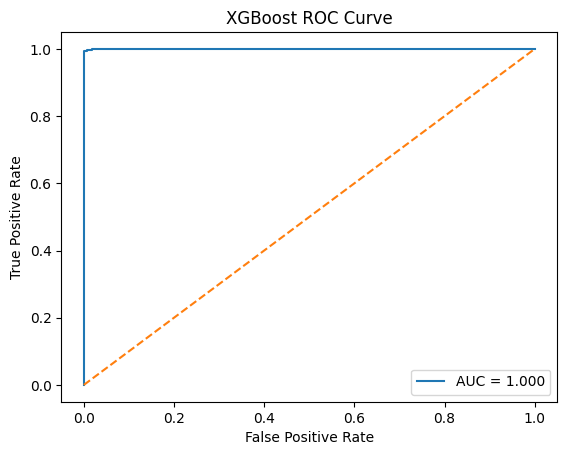

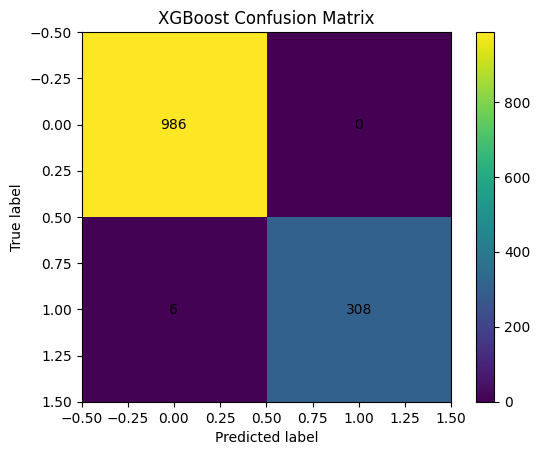

In [14]:
# Predictions
y_pred_proba = bst.predict(dtest)
y_pred = (y_pred_proba > 0.5).astype(int)

# Compute ROC metrics
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend(loc="lower right")
plt.show()

# Plot Confusion Matrix Heatmap
plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.show()
